In [1]:
import math

In [2]:
import random

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
%matplotlib inline

In [6]:
def f(x):
    return 3*x**2

In [7]:
f(3.0)

27.0

In [8]:
f(3)

27

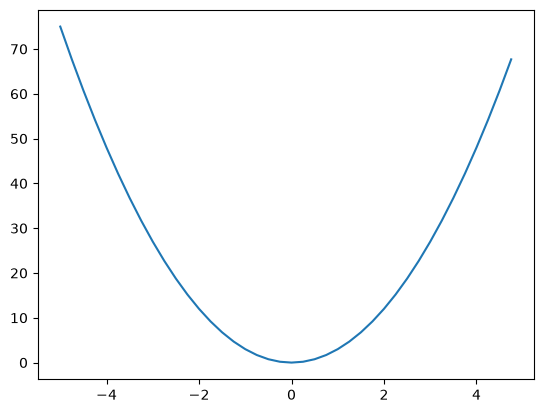

In [9]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [10]:
h=0.0001
def ff(x):
    return (f(x+h)-f(x-h))/(2*h)

In [11]:
zs=ff(xs) 

In [12]:
print(zs)

[-30.  -28.5 -27.  -25.5 -24.  -22.5 -21.  -19.5 -18.  -16.5 -15.  -13.5
 -12.  -10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.    4.5
   6.    7.5   9.   10.5  12.   13.5  15.   16.5  18.   19.5  21.   22.5
  24.   25.5  27.   28.5]


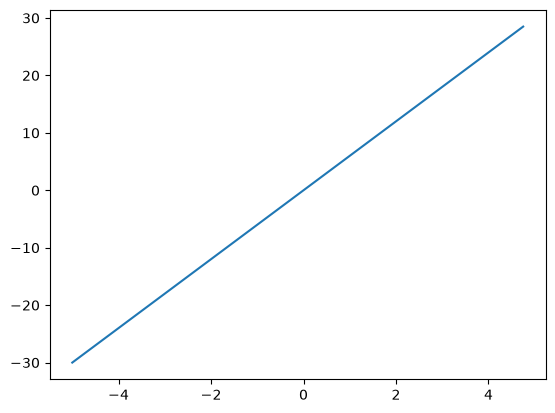

In [13]:
plt.plot(xs,zs)

In [14]:
print(ff(0))

0.0


In [15]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [16]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d1=a*b+c
c+=h
d2=a*b+c
dd=(d2-d1)/h
print('d1 =',d1)
print('d2 =',d2)
print('slope =',dd)

d1 = 4.0
d2 = 4.0001
slope = 0.9999999999976694


In [17]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data  #数值
        self.grad = 0.0  #梯度
        self._prev=set(_children)  #树结构引用
        self._op=_op  #符号
        self.label=label  #标签
        self._backward = lambda: None

    #魔术方法，可以更直观的展示Value
    def __repr__(self):
        return f"Value(data={self.data})"

    #取相反数
    #-a
    def __neg__(self):
        return self*-1
    
    #魔术方法实现运算符重载
    #a+b；a+2
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():  
            #这里所运用的语法是python的闭包
            #python将函数视作对象
            #所以可以直接传递函数到下一个对象
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        return out

    #备用方法
    #2+a
    def __radd__(self,other):
        return self+other

    #a-b
    def __sub__(self,other):
        return self+(-other)
        
    #魔术方法实现运算符重载
    #a*b;a*2
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out

    #备用方案
    #2*a
    def __rmul__(self,other):
        return self*other

    #除法
    #a/b
    def __truediv__(self,other):
        return self*(other**-1)
    
    #幂次函数（other此刻是int或float）
    #a**2
    def __pow__(self,other):
        assert isinstance(other,(int ,float)),"only support int/float powers for now"
        out=Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad+=other*self.data**(other-1)*out.grad
        out._backward=_backward
        return out
        
    #exp函数，计算e的x次方
    def exp(self):
        out=Value(math.exp(self.data),(self,),'exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out

    #压缩函数
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        
        return out

    #反向传播函数
    #利用拓扑结构反向传播求导
    def backward(self):
        topo=[]
        visited=set()
        #拓扑函数，将整个拓扑结构存储到列表topo里
        #采用递归的方式对根节点进行调用
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        #调用根节点
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()
        
        

In [18]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c') 
e=a*b; e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=d*f
L.label='L'
L

Value(data=-8.0)

In [19]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


画图函数，不需要理解，只需要知道下面的图是这个函数画的

In [20]:
f.grad=4.0
d.grad=-2.0
e.grad=-2.0
c.grad=-2.0
a.grad=6.0
b.grad=-4.0

In [21]:
L.grad = 1.0

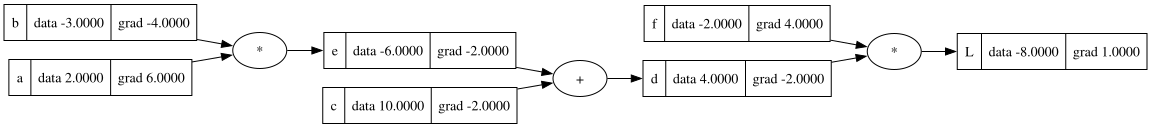

In [22]:
draw_dot(L)

In [23]:
h=0.01
a.data+=h*a.grad
b.data+=h*b.grad
c.data+=h*c.grad
f.data+=h*f.grad

e=a*b
d=e+c
L=d*f

print(L.data)

-7.286496


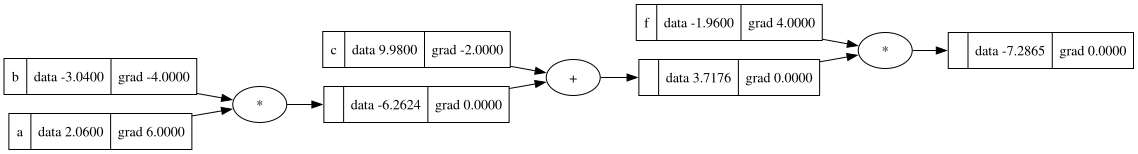

In [24]:
draw_dot(L)

In [25]:
def lol():
    h=0.0001
    
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c') 
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=d*f
    L.label='L'
    L1=L.data

    a=Value(2.0+h,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c') 
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=d*f
    L.label='L'
    L2=L.data

    dd=(L2-L1)/h
    return(dd)

这一个单元格是用来隔离变量的，用来展示导数的求法

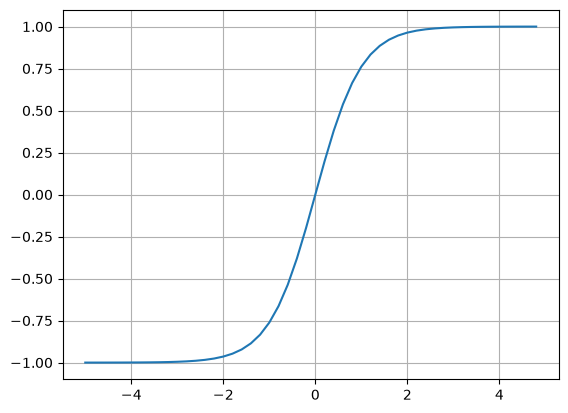

In [26]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

这里这个函数被称作压缩函数。因为即将进入神经元阶段：
神经元的模拟是这样的：
每一个神经元会接收多个神经元传递过来的电信号
电信号会累加，当累加到一定值之后神经元就会放电
现在我们要计算的就是这个累加值
然后关于这个累加值我们需要一个判定标准
于是乎我们就用压缩函数
将算出来的值平滑的压缩到-1～1
这样的话就可以去更灵活的判断这个值的价值与大小
接下来是神经元的具体实现过程

In [27]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1*w1'
x2w2=x2*w2
x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b
n.label='n'

这里的x1x2是input，w1w2是weight，b被称作bias——偏置，这个b不是太重要主要是要让最终结果尽量偏向活跃值，否则当x1x2都为0的时候整个式子就是0了。
最后的式子就是n=x1*w1+x2*w2+b

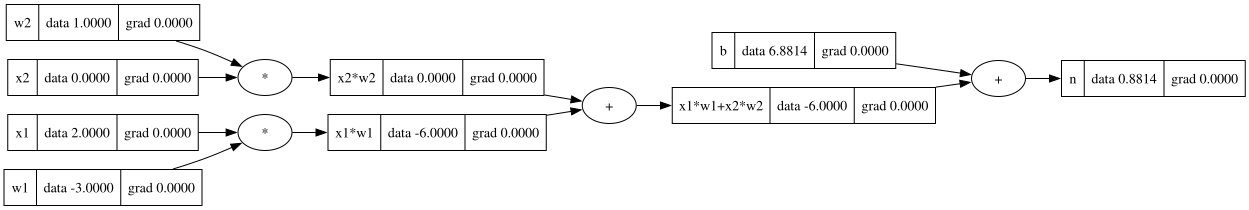

In [28]:
draw_dot(n)

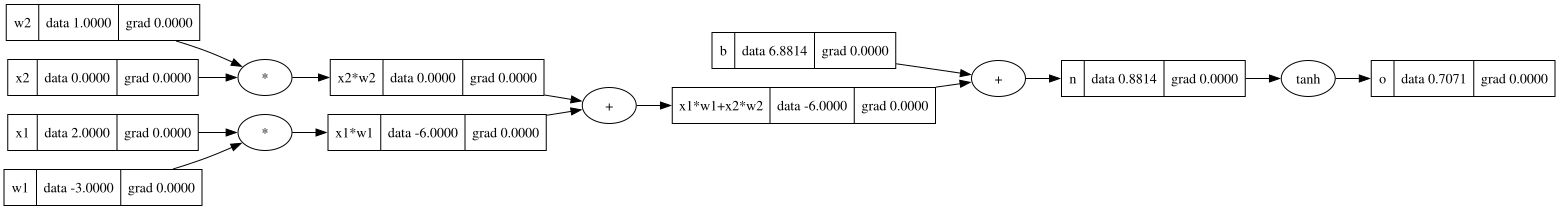

In [29]:
o=n.tanh();o.label='o'
draw_dot(o)

In [30]:
o.grad=1.0

In [31]:
n.grad=1-o.data**2
print(n.grad)

0.4999999999999999


In [32]:
b.grad=n.grad
x1w1x2w2.grad=n.grad
x1w1.grad=n.grad
x2w2.grad=n.grad
x1.grad=x1w1.grad*w1.data
w1.grad=x1w1.grad*x1.data
x2.grad=x2w2.grad*w2.data
w2.grad=x2w2.grad*x2.data

这里是手动反向传播

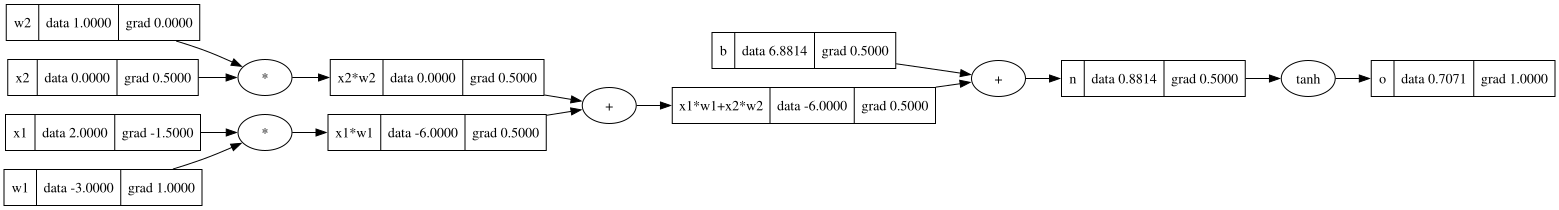

In [33]:
draw_dot(o)

In [34]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1*w1'
x2w2=x2*w2
x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b
n.label='n'
o=n.tanh()
o.label='o'
o.grad=1.0

现在来尝试自动反向传播计算

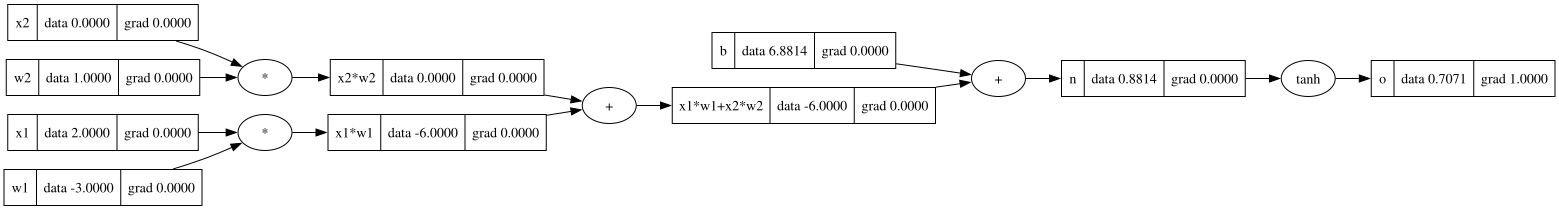

In [35]:
draw_dot(o)

In [36]:
# o.grad=1.0
# o._backward()

In [37]:
# draw_dot(o)

In [38]:
#如你所见，现在我们已经完成了利用函数的反向传播

In [39]:
#现在我们来尝试一下自己实现一个o._backward就能实现所有的_backward

In [40]:
#ok啊也是自己实现了一个自动的反向传播函数

In [41]:
#好像不太对，神经网络好像是可以出现环的
#修改一下逻辑，用拓扑结构来遍历所有的节点从而实现grad的更新
#上面的自动反向传播就先删掉了

In [42]:
topo=[]
visited=set()

#拓扑函数，将整个拓扑结构存储到列表topo里
#采用递归的方式对根节点进行调用
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

#调用根节点
build_topo(o)
topo   

[Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [43]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1*w1'
x2w2=x2*w2
x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b
n.label='n'
o=n.tanh()
o.label='o'
o.grad=1.0

In [44]:
build_topo(o)

for node in reversed(topo):
    node._backward()

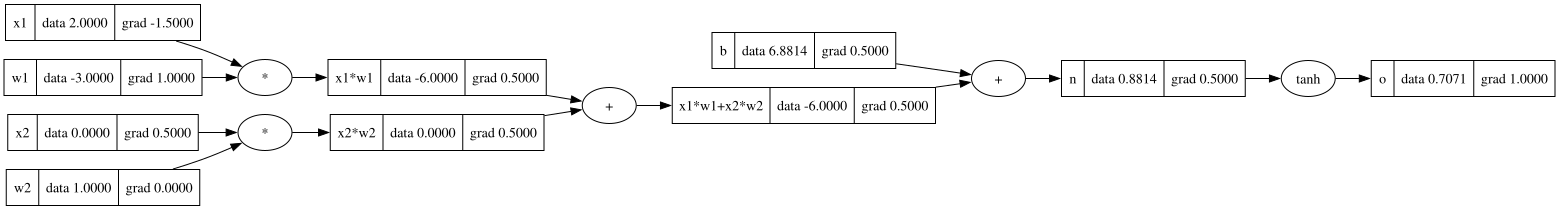

In [45]:
draw_dot(o)

In [46]:
#拓扑反向成功，接下来要尝试将拓扑结构函数直接融入Value类

In [47]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1*w1'
x2w2=x2*w2
x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b
n.label='n'
o=n.tanh()
o.label='o'
o.grad=1.0

In [48]:
o.backward()

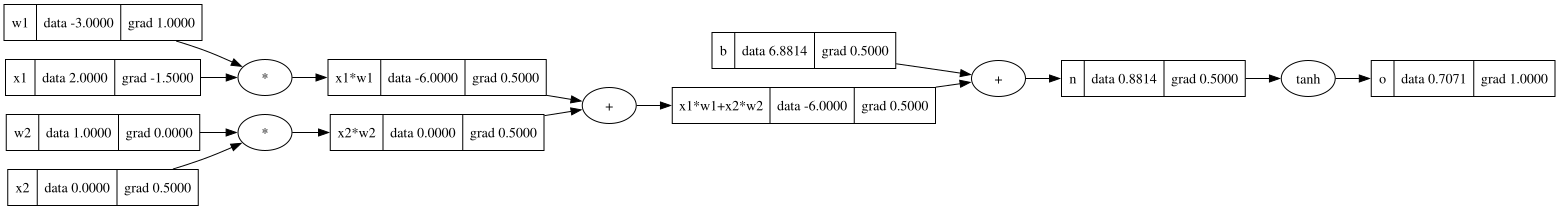

In [49]:
draw_dot(o)

In [50]:
#ok实现了内置函数的反向传播

In [51]:
#存在关键问题！
#反向传播求导只能处理一次函数
#处理不了二次函数或者一个式子里单个数字重复出现
#比如b=a+a
#接下来展示

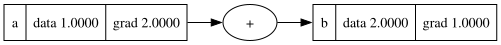

In [52]:
a=Value(1.0,label='a')
b=a+a
b.label='b'
b.backward()
draw_dot(b)

In [53]:
#这里明显出错
#此时a.grad应该是2，但是我们的add算法里直接给self和other的grad赋值为1.0，这里self和other全都是a，被赋值了两遍为1
#再举一个例子

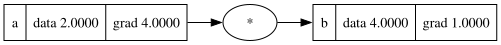

In [54]:
a=Value(2.0,label='a')
b=a*a
b.label='b'
b.backward()
draw_dot(b)

In [55]:
#此时b=a**2,求导应该是2a也就是4；但是还是那个问题：原本是一次的，直接用1.0*a.data=2了

In [56]:
#再来展示一个

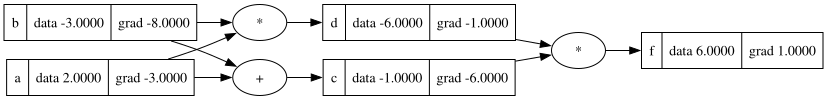

In [57]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=a+b; c.label='c'
d=a*b; d.label='d'
f=c*d;f.label='f'

f.backward()

draw_dot(f)

In [58]:
#这里会发现，其实f=(a+b)*(a*b)=a*a*b+a*b*b,所以a.grad=2ba+b**2,b.grad=2ab+a**2

In [59]:
#Andrej给出的解法是对梯度进行累加而不是赋值
#现在修改完成之后来进行验证

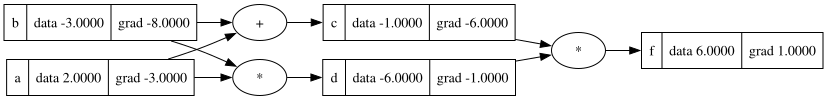

In [60]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=a+b; c.label='c'
d=a*b; d.label='d'
f=c*d;f.label='f'

f.backward()

draw_dot(f)

In [61]:
#现在的结果就是正确的

In [62]:
#现在实现了exp，-，/等函数，现在可以用这些来实现tanh

In [63]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1*w1'
x2w2=x2*w2
x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b
n.label='n'
#============实现tanh
e=(2*n).exp()
e.label='e'
o=(e-1.0)/(e+1.0)
o.label='o'
#============
o.grad=1.0
o.backward()

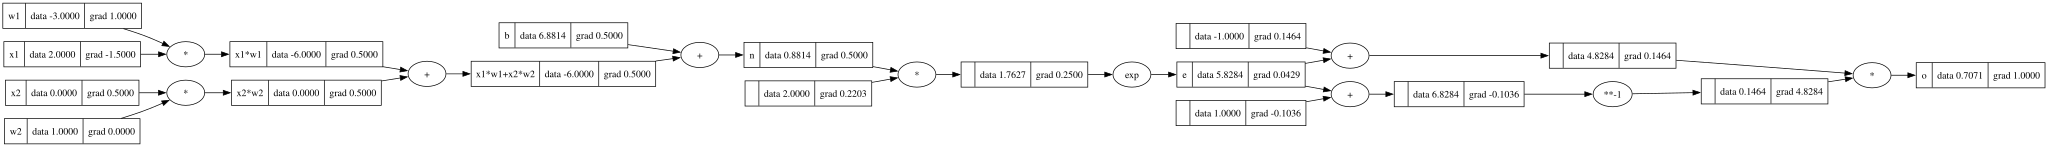

In [64]:
draw_dot(o)

In [65]:
#这里把tanh函数拆开来，可以发现最前面的x1x2w1w2的grad并没有发生变化
#所以反向传播其实是全自动的：我们把简单的运算的导数推导方式写出来就可以自动反向传播而不是需要把所有函数的grad推导都写出来

In [66]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()   ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [67]:
#这里用pytorch代替了手写的Value类来实现之前的o=tanh(x1w1+x2w2+h)
#其中几个pytorch的独有特性：
#1.Tensor是张量的意思，可以理解为pytorch里独有的多维数组，但是可以用于并行化计算
#2..double()的作用是将tensor里每一个值的类型转化为64位的
#3.pytorch默认对于张量是没有grad的，用于节省内存开支，这里手动添加每个变量的grad
#4..item()的作用是吧tensor里的值从pytorch独有的一些dtype类型转化为python本身就能识别的float

In [68]:
class Neuron:#单个神经元
    def __init__(self,nin):#获取神经元的输入数
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]#random.uniform:均匀随机取值
        self.b=Value(random.uniform(-1,1))

    #魔术方法call
    #这样的话可以实现一个Neuron类的实现，如N
    #可以调用例如N(x)的方法来作为函数
    def __call__(self,x):
        act=sum((xi*wi for xi,wi in zip(self.w,x)),self.b)#这里的x可以为Value也可以是int或float
        out=act.tanh()
        return out

    #三层parameters函数用于获取一个大的参数列表
    def parameters(self):#第一层
        return self.w+[self.b]

In [69]:
class Layer:#单层神经元
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]#获取nout个nin维的神经元

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]#每一层去call一下，意味着这nout个神经元接收的输入是一样的
        return outs[0] if len(outs)==1 else outs#当最后只有一个结果的时候只返回单独值而不是列表

    def parameters(self):#第二层parameters
        return[p for neurons in self.neurons for p in neurons.parameters()]

In [70]:
x=[2.0,3.0]
n=Layer(2,3)
n(x)

[Value(data=-0.9811011311175705),
 Value(data=0.976977216084596),
 Value(data=-0.9852933077581151)]

In [71]:
#这里实现了一个3个神经元的单层神经元，每个神经元接收x的两个输入
#而且n(x)结果显然也是一个列表，可以继续作为下一层的输入

In [72]:
x=[2.0,3.0,-4.0]
n1=Layer(3,4)
n2=Layer(4,4)
n3=Layer(4,1)
out=n3(n2(n1(x)))
out

Value(data=-0.055184222256044635)

In [73]:
#这里实现了一个多层的神经网络，第一层是两个x的输入
#两个x经过第一层的三个神经元产生三个输出
#第二层经过四个神经元产生四个输出
#最后一层一个神经元产生一个输出
#得到最后的data

In [74]:
out.backward()

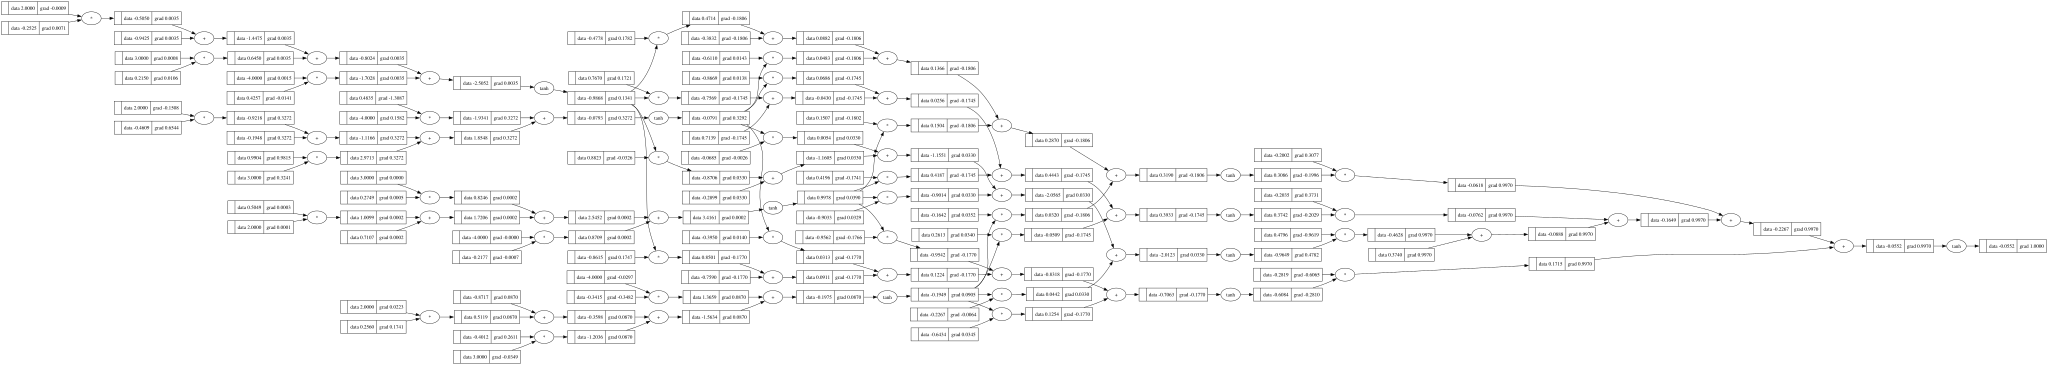

In [75]:
draw_dot(out)

In [76]:
#实现了一个超震撼的大神经网络，两个数字经过一系列传导之后诞生了一个超大的网络
#现在我们来尝试把这个多层的也包装成类

In [77]:
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts#这里是size的意思
        #nin是第一层x的数量
        #转换成列表
        #nouts是每一层神经元的数量
        #组合就是[x,n1,n2,...]
        self.layers=[Layer(sz[i],sz[i+1])for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)#递归一层一层联系上
        return x
    #最终的结果就是输入一个x和结构就可以实现这个MLP
    #最终结果就是最后一层的输出

    def parameters(self):#第三层parameters
        return[p for layers in self.layers for p in layers.parameters()]

In [78]:
x=[2.0,3.0,-4.0]
nouts=[4,4,1]
m=MLP(3,nouts)
out=m(x)
out

Value(data=0.7617125108754519)

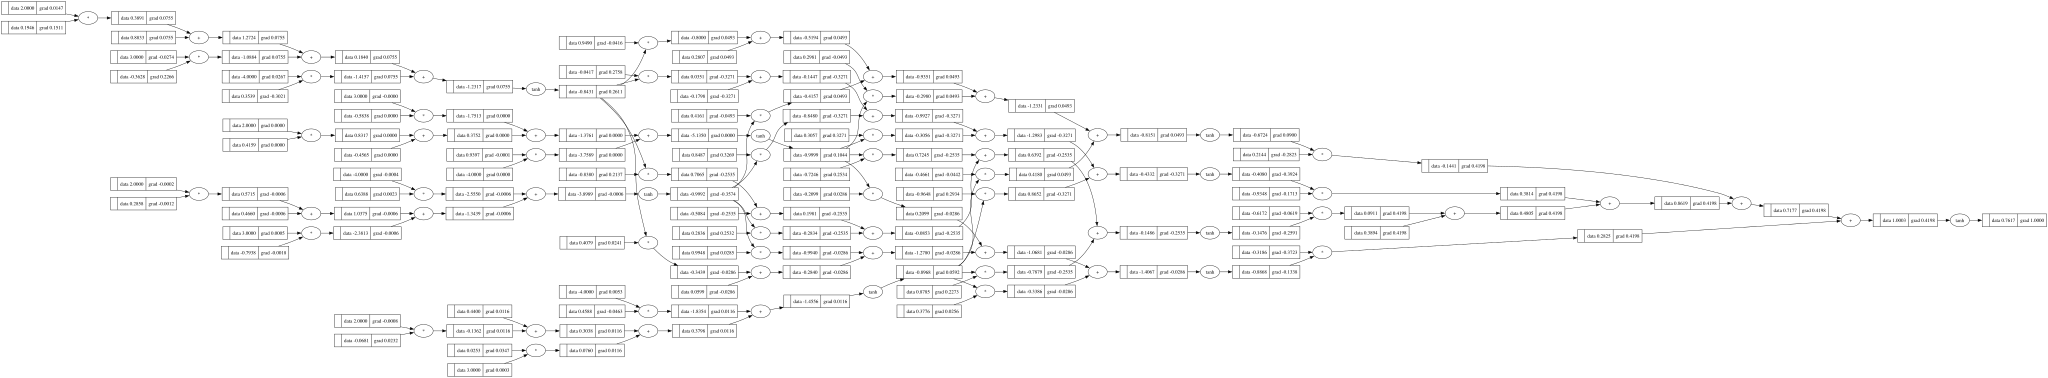

In [79]:
out.backward()
draw_dot(out)

In [80]:
#可见这个新的MLP和我们之前实现的MLP结构一样

In [81]:
#现在我们来尝试用这个实现一个简单的二进制预测

In [82]:
#这里xs是四组输入，ys是四组答案，现在的想法是训练一个神经网络，让他接收到xs的输入之后可以去预测对应的ys
#就像llm用大量的输入输出组合去训练模型
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,1.0]
]
ys=[1.0,-1.0,-1.0,1.0]
n=MLP(3,[4,4,1])#和前面的模型的结构是一样的
ypred=[n(x) for x in xs]
ypred

[Value(data=0.057152320401920316),
 Value(data=0.5642095487419705),
 Value(data=0.580393588470323),
 Value(data=0.5161987864092104)]

In [83]:
#这里可以看出模型的预测和目标结果有出入
#下一步要做的就是实现模型的训练，也就是微调
#使得模型变得“聪明”以至于可以预测ys 
#所以我们去定义一个值loss
#来衡量模型的准确度

In [84]:
#loss的思路是判断它和正确值差多少

In [85]:
loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
loss

Value(data=6.067420768049068)

In [86]:
#这里可以看到，loss关心的是差距之和 
#所以根据结果我们可以判断出来这个loss应该也是可以直接反向传播的

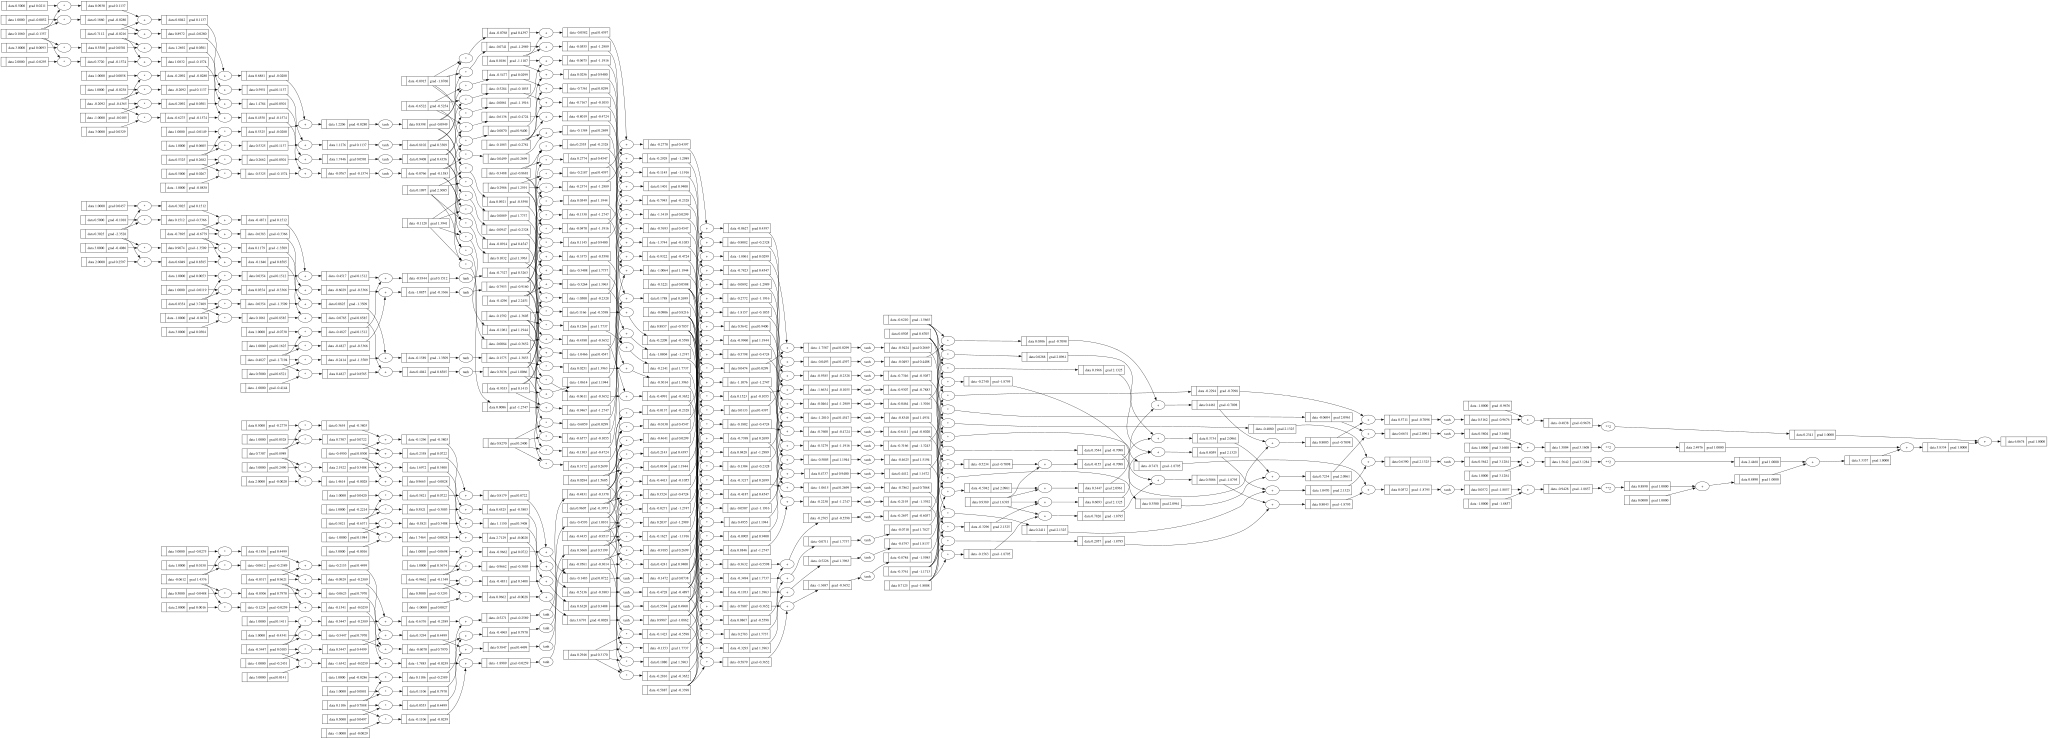

In [87]:
loss.backward()
draw_dot(loss)

In [88]:
#非常壮观是不是

In [89]:
#现在我们可以来进行训练了
#首先我们要意识到一点就是
#之前我们创建MLP的时候，Layer和Neuron是他的成员变量
#也就是说我们可以去操作单独的w
#例如：

In [90]:
print(n.layers[0].neurons[0].w[0])

Value(data=0.18600286614652983)


In [91]:
#可以看到我们可以直接去操控每一个节点的w
#所以接下来我们给这个MLP新增一个parameters函数
#用于遍历所有的w和b
#那接下来我们可以开始微调训练了

In [92]:
#先获取parameters

In [93]:
params=n.parameters()
print(params)

[Value(data=0.18600286614652983), Value(data=-0.20915322400494962), Value(data=0.5324886383028429), Value(data=0.7112409151372105), Value(data=0.30246616494045897), Value(data=0.035361465919847346), Value(data=-0.48273815948626697), Value(data=-0.789531858286354), Value(data=-0.06119835281868835), Value(data=-0.5447287764783191), Value(data=0.11057307743388023), Value(data=-0.031707923180329445), Value(data=0.7307183869718226), Value(data=0.582144935804211), Value(data=-0.9661737945903424), Value(data=-0.4949677736107627), Value(data=-0.11276969315150986), Value(data=-0.34878326342845867), Value(data=0.028385064497570056), Value(data=0.8857261123931055), Value(data=-0.9552834594198172), Value(data=-0.09149329657646454), Value(data=0.29855489041476746), Value(data=-0.44351810949826787), Value(data=-0.09060951085011149), Value(data=0.018621306930672432), Value(data=-0.6521929120945553), Value(data=0.8269648615012433), Value(data=0.9606734686215694), Value(data=-0.3221081712123126), Value

In [94]:
#接下来开始微调
#先来看下目前的xs，ys，ypred是多少

In [95]:
print("xs:",xs)
print("ys:",ys)
print("ypred:",ypred)

xs: [[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, 1.0]]
ys: [1.0, -1.0, -1.0, 1.0]
ypred: [Value(data=0.057152320401920316), Value(data=0.5642095487419705), Value(data=0.580393588470323), Value(data=0.5161987864092104)]


In [96]:
h=0.0001
for i in range(300):#训练300轮
    loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
    loss.backward()
    for param in params:
        param.data-=param.grad*h
    ypred=[n(x) for x in xs]
    print(loss)

Value(data=6.067420768049068)
Value(data=5.984762883347814)
Value(data=5.894967142863866)
Value(data=5.7980258951103885)
Value(data=5.693995510414786)
Value(data=5.583014878250408)
Value(data=5.465325298223152)
Value(data=5.341290557506727)
Value(data=5.2114154145401725)
Value(data=5.076360151996883)
Value(data=4.936948457695785)
Value(data=4.794165815884531)
Value(data=4.649146020323803)
Value(data=4.5031444686290625)
Value(data=4.357498537558447)
Value(data=4.213577347497337)
Value(data=4.072725186756136)
Value(data=3.9362042732369718)
Value(data=3.8051429481119294)
Value(data=3.6804946402396244)
Value(data=3.563011173396924)
Value(data=3.453231672517239)
Value(data=3.3514860497475567)
Value(data=3.2579103223667047)
Value(data=3.172470102375674)
Value(data=3.094988499483942)
Value(data=3.025175190459818)
Value(data=2.962654240461947)
Value(data=2.9069891525520424)
Value(data=2.857704391962023)
Value(data=2.814303200364325)
Value(data=2.7762818764231403)
Value(data=2.7431408894512277)

In [97]:
#可以看到loss在稳步下降,但是有起伏，因为我们可能会错过正确答案
#现在再来看看ypred和ys的差距

In [98]:
print("ys:",ys)
print("ypred:",ypred)

ys: [1.0, -1.0, -1.0, 1.0]
ypred: [Value(data=0.997383573647556), Value(data=-0.993949905510366), Value(data=-0.674633226799696), Value(data=0.5737785988025109)]


In [99]:
#可以看出ypred明显接近正确答案，但存在显著差距，而且分析之前的训练过程发现loss并非稳定下降，而是存在波动性
#所以现在我们可以尝试一点：就是我们期望loss下降到一个很小的值，比如0.01以下之后我们就可以暂停了

In [100]:
while(loss.data>0.01):#训练到loss<0.01
    loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
    loss.backward()
    for param in params:
        param.data-=param.grad*h
    ypred=[n(x) for x in xs]
    print(loss)

Value(data=0.2875716692717203)
Value(data=0.23037845409498273)
Value(data=0.1991411215837847)
Value(data=0.19020360594892952)
Value(data=0.19894064899308578)
Value(data=0.22171300598104537)
Value(data=0.25639230873313484)
Value(data=0.3019364503837458)
Value(data=0.3575633766185861)
Value(data=0.42183122031765236)
Value(data=0.49181778080788685)
Value(data=0.5626320460994153)
Value(data=0.6275194169977061)
Value(data=0.6786861685232324)
Value(data=0.7086872940164896)
Value(data=0.7119934532818176)
Value(data=0.6863276139919666)
Value(data=0.6334581550022504)
Value(data=0.5591865238491158)
Value(data=0.47231661997080165)
Value(data=0.3826809024790955)
Value(data=0.2988467808801798)
Value(data=0.2264631777076829)
Value(data=0.16786178618218497)
Value(data=0.12275464060143643)
Value(data=0.0893785532936411)
Value(data=0.06551145494892288)
Value(data=0.0491330384531904)
Value(data=0.03877590615797221)
Value(data=0.03371553040116072)
Value(data=0.034136760364919055)
Value(data=0.04134907040

In [101]:
print("ys:",ys)
print("ypred:",ypred)

ys: [1.0, -1.0, -1.0, 1.0]
ypred: [Value(data=0.9983177205569979), Value(data=-0.9990456671865661), Value(data=-0.9607244324868691), Value(data=0.9422950871108858)]


In [102]:
#训练成功，模型非常准确